# AI Load Balancer — XGBoost Training Pipeline
**Thesis:** Implementation of AI Based Load Balancing on Web Server Network using GNS3

---
### Struktur File yang Dibutuhkan
```
project/
├── xgboost_load_balancer.ipynb  ← file ini
├── final_RR_ws1.csv
├── final_RR_ws2.csv
├── final_LC_ws1.csv
├── final_LC_ws2.csv
├── Result_final_RR.csv
├── Result_Final_LC.csv
└── model/                       ← folder output (dibuat otomatis)
```
> `final_summary_RR.csv` dan `final_summary_LC.csv` **tidak dipakai** untuk training — hanya ringkasan statistik.

## Step 0 — Install & Import Library

In [1]:
# Install library yang dibutuhkan (jalankan sekali saja jika belum ter-install)
#!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings('ignore')
os.makedirs('model', exist_ok=True)

print('✅ Semua library berhasil di-import.')

✅ Semua library berhasil di-import.


---
## Step 1 — Konfigurasi Path File CSV

In [3]:
# ============================================================
#  KONFIGURASI — sesuaikan path jika file berada di folder lain
# ============================================================

# File metrik server (format dool/dstat)
PATH_RR_WS1 = 'Dataset/final_RR_ws1.csv'
PATH_RR_WS2 = 'Dataset/final_RR_ws2.csv'
PATH_LC_WS1 = 'Dataset/final_LC_ws1.csv'
PATH_LC_WS2 = 'Dataset/final_LC_ws2.csv'

# File log JMeter (raw HTTP request)
PATH_RR_JM  = 'Dataset/Result_final_RR.csv'
PATH_LC_JM  = 'Dataset/Result_Final_LC.csv'

# Output model
PATH_MODEL  = 'model/xgb_load_balancer.pkl'

print('✅ Konfigurasi siap.')

✅ Konfigurasi siap.


---
## Step 2 — Load & Parsing File Dool (Server Metrics)

File dool memiliki **5 baris header** sebelum data aktual dimulai.
Kolom aslinya: `usr, sys, idl, wai, stl, used, free, cach, avai, recv, send`

Yang kita butuhkan:
- **CPU_Usage_Percent** = `100 - idl` (CPU aktif)
- **RAM_Used_MB** = `used / 1024²`
- **Net_Recv_KB** = `recv / 1024`
- **Timestamp** = dibuat dari nomor baris (index ke-N = detik ke-N)

In [4]:
def load_dool(path, label=''):
    """
    Membaca file CSV dari dool (monitoring tool).
    - Skip 5 baris header dool
    - Hitung CPU aktif, RAM dalam MB, Network dalam KB
    - Buat kolom Timestamp dari index baris (detik ke-N)
    """
    # Baca CSV, lewati 5 baris header dool
    df = pd.read_csv(path, skiprows=5, header=0)

    # Berikan nama kolom yang jelas
    df.columns = [
        'cpu_usr', 'cpu_sys', 'cpu_idl', 'cpu_wai', 'cpu_stl',
        'mem_used_bytes', 'mem_free_bytes', 'mem_cach_bytes', 'mem_avai_bytes',
        'net_recv_bytes', 'net_send_bytes'
    ]

    # Konversi semua kolom ke numerik, paksa error jadi NaN
    df = df.apply(pd.to_numeric, errors='coerce')

    # Hapus baris yang semua kolomnya NaN (baris kosong atau header duplikat)
    df.dropna(how='all', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── Hitung metrik yang dibutuhkan
    # CPU aktif = 100% dikurangi idle
    df['CPU_Usage_Percent'] = (100 - df['cpu_idl']).clip(0, 100)

    # RAM dalam MB
    df['RAM_Used_MB'] = df['mem_used_bytes'] / (1024 ** 2)

    # Network received dalam KB/s
    df['Net_Recv_KB'] = df['net_recv_bytes'] / 1024

    # Timestamp = index baris (tiap baris = 1 detik)
    df['Timestamp'] = df.index

    # Tandai sumber data (RR atau LC) — berguna untuk analisis
    df['source'] = label

    # Pilih hanya kolom yang relevan
    result = df[['Timestamp', 'CPU_Usage_Percent', 'RAM_Used_MB', 'Net_Recv_KB', 'source']].copy()

    # Isi missing values dengan median kolom
    for col in ['CPU_Usage_Percent', 'RAM_Used_MB', 'Net_Recv_KB']:
        result[col].fillna(result[col].median(), inplace=True)

    return result


# Load semua file server
rr_ws1 = load_dool(PATH_RR_WS1, label='RR')
rr_ws2 = load_dool(PATH_RR_WS2, label='RR')
lc_ws1 = load_dool(PATH_LC_WS1, label='LC')
lc_ws2 = load_dool(PATH_LC_WS2, label='LC')

print('=== Preview RR WS1 ===')
display(rr_ws1.head())
print(f'\nJumlah baris → RR WS1: {len(rr_ws1)} | RR WS2: {len(rr_ws2)} | LC WS1: {len(lc_ws1)} | LC WS2: {len(lc_ws2)}')

=== Preview RR WS1 ===


,Timestamp,CPU_Usage_Percent,RAM_Used_MB,Net_Recv_KB,source
0,0,15.634,443.171875,0.000000,RR
1,1,1.042,443.171875,4.515625,RR
2,2,0.000,443.171875,2.953125,RR
3,3,0.000,443.171875,1.093750,RR
4,4,0.000,443.171875,2.953125,RR



Jumlah baris → RR WS1: 489 | RR WS2: 489 | LC WS1: 1326 | LC WS2: 1327


---
## Step 3 — Load & Parsing File JMeter

Kolom asli JMeter: `timeStamp, elapsed, label, responseCode, responseMessage, threadName, success, Latency`

Penyesuaian:
- **Response_Time_ms** = kolom `elapsed`
- **Is_Error** = kebalikan dari `success` (True = sukses = **bukan** error → Is_Error = 0)

In [5]:
def load_jmeter(path, label=''):
    """
    Membaca file hasil JMeter.
    - Rename kolom 'elapsed' → 'Response_Time_ms'
    - Buat kolom 'Is_Error' dari kebalikan 'success'
    - Normalisasi Timestamp ke detik relatif (mulai dari 0)
    """
    df = pd.read_csv(path)

    # Rename kolom agar konsisten
    df.rename(columns={
        'elapsed'   : 'Response_Time_ms',
        'timeStamp' : 'ts_raw'
    }, inplace=True)

    # Is_Error = 1 jika request GAGAL (success=False atau success='false')
    # Tangani kemungkinan nilai string 'true'/'false'
    if df['success'].dtype == object:
        df['Is_Error'] = df['success'].str.lower().map({'true': 0, 'false': 1})
    else:
        df['Is_Error'] = (~df['success'].astype(bool)).astype(int)

    # Timestamp relatif dalam detik (mulai dari 0)
    df['Timestamp'] = ((df['ts_raw'] - df['ts_raw'].min()) / 1000).astype(int)

    df['source'] = label

    result = df[['Timestamp', 'Response_Time_ms', 'Is_Error', 'source']].copy()
    result.dropna(inplace=True)

    return result


# Load semua file JMeter
rr_jm = load_jmeter(PATH_RR_JM, label='RR')
lc_jm = load_jmeter(PATH_LC_JM, label='LC')

print('=== Preview RR JMeter ===')
display(rr_jm.head())
print(f'\nJumlah request → RR: {len(rr_jm)} | LC: {len(lc_jm)}')
print(f'Error RR : {rr_jm["Is_Error"].sum()} ({rr_jm["Is_Error"].mean()*100:.2f}%)')
print(f'Error LC : {lc_jm["Is_Error"].sum()} ({lc_jm["Is_Error"].mean()*100:.2f}%)')

=== Preview RR JMeter ===


,Timestamp,Response_Time_ms,Is_Error,source
0,0,169,0,RR
1,0,128,0,RR
2,0,263,0,RR
3,0,214,0,RR
4,0,300,0,RR



Jumlah request → RR: 6000 | LC: 6000
Error RR : 26 (0.43%)
Error LC : 25 (0.42%)


---
## Step 4 — Gabungkan (Concatenate) RR + LC

Semua data RR dan LC digabung menjadi satu dataset training.
Timestamp di-reset ulang agar tidak tumpang tindih antara RR dan LC.

In [6]:
def concat_and_reindex(df1, df2):
    """
    Gabungkan dua DataFrame dan reset Timestamp agar berurutan.
    RR mendapat Timestamp 0..N, LC mendapat Timestamp N+1..M.
    """
    offset = df1['Timestamp'].max() + 1
    df2 = df2.copy()
    df2['Timestamp'] = df2['Timestamp'] + offset
    combined = pd.concat([df1, df2], ignore_index=True)
    return combined


# Gabungkan WS1 (RR + LC)
all_ws1 = concat_and_reindex(rr_ws1, lc_ws1)

# Gabungkan WS2 (RR + LC)
all_ws2 = concat_and_reindex(rr_ws2, lc_ws2)

# Gabungkan JMeter (RR + LC)
all_jm  = concat_and_reindex(rr_jm,  lc_jm)

print(f'Dataset gabungan:')
print(f'  WS1  : {len(all_ws1)} baris (RR={len(rr_ws1)} + LC={len(lc_ws1)})')
print(f'  WS2  : {len(all_ws2)} baris (RR={len(rr_ws2)} + LC={len(lc_ws2)})')
print(f'  JMeter: {len(all_jm)} request (RR={len(rr_jm)} + LC={len(lc_jm)})')

display(all_ws1.head())

Dataset gabungan:
  WS1  : 1815 baris (RR=489 + LC=1326)
  WS2  : 1816 baris (RR=489 + LC=1327)
  JMeter: 12000 request (RR=6000 + LC=6000)


,Timestamp,CPU_Usage_Percent,RAM_Used_MB,Net_Recv_KB,source
0,0,15.634,443.171875,0.000000,RR
1,1,1.042,443.171875,4.515625,RR
2,2,0.000,443.171875,2.953125,RR
3,3,0.000,443.171875,1.093750,RR
4,4,0.000,443.171875,2.953125,RR


---
## Step 5 — Agregasi JMeter per Detik

In [7]:
# Ringkas JMeter per detik:
#   avg_rt     = rata-rata response time
#   total_req  = jumlah request
#   total_err  = jumlah request error
#   error_rate = proporsi error (0.0 - 1.0)
jm_agg = all_jm.groupby('Timestamp').agg(
    avg_rt    = ('Response_Time_ms', 'mean'),
    total_req = ('Response_Time_ms', 'count'),
    total_err = ('Is_Error',         'sum')
).reset_index()

jm_agg['error_rate'] = jm_agg['total_err'] / jm_agg['total_req']

print(f'JMeter teragregasi: {len(jm_agg)} detik')
display(jm_agg.head(10))

JMeter teragregasi: 877 detik


,Timestamp,avg_rt,total_req,total_err,error_rate
0,0,275.714286,14,0,0.0
1,1,793.733333,15,0,0.0
2,2,855.117647,17,0,0.0
3,3,1240.266667,15,0,0.0
4,4,2081.789474,19,0,0.0
5,5,2194.714286,14,0,0.0
6,6,2557.062500,16,0,0.0
7,7,3403.133333,15,0,0.0
8,8,3415.333333,18,0,0.0
9,9,3784.666667,15,0,0.0


---
## Step 6 — Merge: Gabungkan WS1 + WS2 + JMeter

In [8]:
# Rename kolom WS1 dan WS2 agar tidak bentrok saat merge
ws1_renamed = all_ws1.rename(columns={
    'CPU_Usage_Percent': 'cpu_ws1',
    'RAM_Used_MB'      : 'ram_ws1',
    'Net_Recv_KB'      : 'net_ws1'
})

ws2_renamed = all_ws2.rename(columns={
    'CPU_Usage_Percent': 'cpu_ws2',
    'RAM_Used_MB'      : 'ram_ws2',
    'Net_Recv_KB'      : 'net_ws2'
})

# Merge WS1 + WS2
df = pd.merge(
    ws1_renamed[['Timestamp', 'cpu_ws1', 'ram_ws1', 'net_ws1', 'source']],
    ws2_renamed[['Timestamp', 'cpu_ws2', 'ram_ws2', 'net_ws2']],
    on='Timestamp', how='inner'
)

# Merge dengan JMeter
df = pd.merge(df, jm_agg, on='Timestamp', how='inner')

df.reset_index(drop=True, inplace=True)

print(f'Dataset gabungan akhir: {df.shape[0]} baris × {df.shape[1]} kolom')
display(df.head(10))
print('\nDistribusi sumber data:')
print(df['source'].value_counts())

Dataset gabungan akhir: 877 baris × 12 kolom


,Timestamp,cpu_ws1,ram_ws1,net_ws1,source,cpu_ws2,ram_ws2,net_ws2,avg_rt,total_req,total_err,error_rate
0,0,15.634,443.171875,0.000000,RR,14.417,457.015625,0.000000,275.714286,14,0,0.0
1,1,1.042,443.171875,4.515625,RR,1.042,457.003906,4.515625,793.733333,15,0,0.0
2,2,0.000,443.171875,2.953125,RR,0.000,457.003906,2.953125,855.117647,17,0,0.0
3,3,0.000,443.171875,1.093750,RR,0.000,457.003906,1.093750,1240.266667,15,0,0.0
4,4,0.000,443.171875,2.953125,RR,0.000,457.003906,2.953125,2081.789474,19,0,0.0
5,5,0.000,443.171875,1.093750,RR,0.000,457.003906,1.093750,2194.714286,14,0,0.0
6,6,0.000,443.171875,0.000000,RR,0.000,457.003906,0.000000,2557.062500,16,0,0.0
7,7,0.000,443.171875,1.093750,RR,0.000,457.003906,1.093750,3403.133333,15,0,0.0
8,8,0.000,443.171875,2.953125,RR,0.000,457.003906,2.953125,3415.333333,18,0,0.0
9,9,0.000,443.171875,1.093750,RR,0.000,457.003906,1.093750,3784.666667,15,0,0.0



Distribusi sumber data:
source
RR    489
LC    388
Name: count, dtype: int64


---
## Step 7 — Feature Engineering

In [9]:
# ── Fitur selisih antar server
df['cpu_diff'] = df['cpu_ws1'] - df['cpu_ws2']   # positif = WS1 lebih berat
df['ram_diff'] = df['ram_ws1'] - df['ram_ws2']
df['net_diff'] = df['net_ws1'] - df['net_ws2']

# ── Composite load score per server
#    Bobot: CPU 50%, RAM 30%, Network 20%
#    RAM dan Network dinormalisasi ke skala 0–100 terlebih dahulu
RAM_MAX = max(df['ram_ws1'].max(), df['ram_ws2'].max())
NET_MAX = max(df['net_ws1'].max(), df['net_ws2'].max())

df['load_ws1'] = (
    0.50 * df['cpu_ws1'] +
    0.30 * (df['ram_ws1'] / RAM_MAX * 100) +
    0.20 * (df['net_ws1'] / NET_MAX * 100).clip(0, 100)
)

df['load_ws2'] = (
    0.50 * df['cpu_ws2'] +
    0.30 * (df['ram_ws2'] / RAM_MAX * 100) +
    0.20 * (df['net_ws2'] / NET_MAX * 100).clip(0, 100)
)

df['load_diff'] = df['load_ws1'] - df['load_ws2']

# ── Rolling average (window 5 detik) — menangkap tren jangka pendek
df['cpu_ws1_roll5']  = df['cpu_ws1'].rolling(5, min_periods=1).mean()
df['cpu_ws2_roll5']  = df['cpu_ws2'].rolling(5, min_periods=1).mean()
df['rt_roll5']       = df['avg_rt'].rolling(5, min_periods=1).mean()
df['load_ws1_roll5'] = df['load_ws1'].rolling(5, min_periods=1).mean()
df['load_ws2_roll5'] = df['load_ws2'].rolling(5, min_periods=1).mean()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset setelah feature engineering: {df.shape}')
display(df.describe().round(2))

Dataset setelah feature engineering: (877, 23)


,Timestamp,cpu_ws1,ram_ws1,net_ws1,cpu_ws2,ram_ws2,net_ws2,avg_rt,total_req,total_err,...,ram_diff,net_diff,load_ws1,load_ws2,load_diff,cpu_ws1_roll5,cpu_ws2_roll5,rt_roll5,load_ws1_roll5,load_ws2_roll5
count,877.00,877.00,877.00,877.00,877.00,877.00,877.00,877.00,877.00,877.00,...,877.00,877.00,877.00,877.00,877.00,877.00,877.00,877.00,877.00,877.00
mean,438.14,89.23,727.63,505.98,74.01,730.08,529.96,21423.43,13.68,0.06,...,-2.45,-23.98,76.49,69.21,7.28,89.02,73.80,21419.14,76.35,69.07
std,253.54,27.33,94.11,348.31,34.28,97.59,410.49,9484.96,5.36,0.41,...,38.10,397.68,17.15,20.73,18.01,26.28,32.98,9231.75,16.75,20.13
min,0.00,0.00,433.01,0.00,0.00,453.31,0.00,275.71,1.00,0.00,...,-31.41,-1715.53,16.30,16.68,-49.95,0.00,0.00,275.71,16.30,16.82
25%,219.00,100.00,728.56,251.26,57.29,709.29,232.32,14172.42,10.00,0.00,...,-16.38,-167.44,78.25,64.67,-0.80,98.30,60.05,14655.16,77.79,66.29
50%,438.00,100.00,755.14,400.26,92.55,764.93,345.04,21992.35,14.00,0.00,...,-9.82,-7.59,81.94,78.43,0.16,100.00,84.84,21576.25,81.89,77.06
75%,657.00,100.00,796.07,710.31,100.00,803.93,874.35,29628.20,17.00,0.00,...,-7.51,72.52,83.46,82.45,10.42,100.00,100.00,29919.56,83.05,82.30
max,880.00,100.00,815.63,1902.17,100.00,807.38,1978.36,42568.55,34.00,5.00,...,186.70,1536.07,97.04,98.10,72.30,100.00,100.00,38579.04,94.55,93.89


---
## Step 8 — Label Creation (Target Y)

**Logika:**
- **Label 0** → Route ke WS1 (WS1 lebih ringan)
- **Label 1** → Route ke WS2 (WS2 lebih ringan)

=== Distribusi Label (Smoothing 3 detik ke depan) ===
  Label 0 (WS1 lebih ringan):   437 sampel (50.0%)
  Label 1 (WS2 lebih ringan):   437 sampel (50.0%)

  Total sampel setelah shift: 874 (berkurang 3 baris dari ujung)

  ✅ Verifikasi anti-leakage & Smoothing:
     Fitur diambil dari timestep T
     Label diambil dari RATA-RATA load score pada T+1 hingga T+3
     → Model belajar mengenali TREN masa depan, mengabaikan noise/spike sesaat


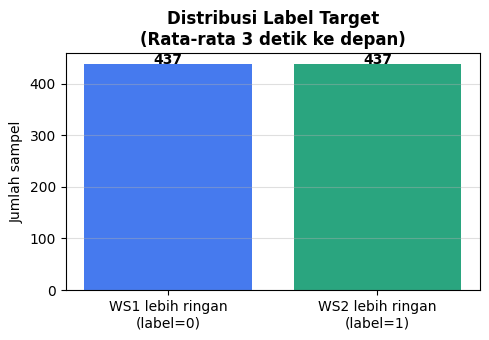

In [10]:
## ============================================================
## PATCH — Step 8: Label Creation (Future Smoothing)
## Prediksi server mana yang RATA-RATA lebih ringan 3 detik ke depan
## ============================================================

# Kita tidak lagi melihat 1 titik, tapi mengambil rata-rata 3 detik ke depan
SMOOTHING_WINDOW = 3 

# ── Geser dan ratakan load score ke depan
#    future_load_ws1 sekarang berisi rata-rata load_ws1 pada T+1, T+2, dan T+3
df['future_load_ws1'] = (df['load_ws1'].shift(-1) + df['load_ws1'].shift(-2) + df['load_ws1'].shift(-3)) / 3
df['future_load_ws2'] = (df['load_ws2'].shift(-1) + df['load_ws2'].shift(-2) + df['load_ws2'].shift(-3)) / 3

# ── Buat label berdasarkan kondisi MASA DEPAN YANG SUDAH DIRATAKAN
#    Label 0 = Rata-rata WS1 lebih ringan selama 3 detik ke depan → route ke WS1
#    Label 1 = Rata-rata WS2 lebih ringan selama 3 detik ke depan → route ke WS2
df['target'] = (df['future_load_ws2'] < df['future_load_ws1']).astype(int)

# Hapus baris terakhir yang tidak punya data masa depan (NaN akibat shift)
df.dropna(subset=['future_load_ws1', 'future_load_ws2', 'target'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Tampilkan distribusi label
label_counts = df['target'].value_counts().sort_index()
print(f'=== Distribusi Label (Smoothing {SMOOTHING_WINDOW} detik ke depan) ===')
print(f'  Label 0 (WS1 lebih ringan): {label_counts.get(0,0):>5} sampel ({label_counts.get(0,0)/len(df)*100:.1f}%)')
print(f'  Label 1 (WS2 lebih ringan): {label_counts.get(1,0):>5} sampel ({label_counts.get(1,0)/len(df)*100:.1f}%)')
print(f'\n  Total sampel setelah shift: {len(df)} (berkurang {SMOOTHING_WINDOW} baris dari ujung)')

# Verifikasi: fitur dan label TIDAK dari timestep yang sama
print(f'\n  ✅ Verifikasi anti-leakage & Smoothing:')
print(f'     Fitur diambil dari timestep T')
print(f'     Label diambil dari RATA-RATA load score pada T+1 hingga T+{SMOOTHING_WINDOW}')
print(f'     → Model belajar mengenali TREN masa depan, mengabaikan noise/spike sesaat')

# Plot distribusi
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(
    [f'WS1 lebih ringan\n(label=0)', f'WS2 lebih ringan\n(label=1)'],
    [label_counts.get(0, 0), label_counts.get(1, 0)],
    color=['#2563EB', '#059669'], alpha=0.85, edgecolor='none'
)
ax.set_title(f'Distribusi Label Target\n(Rata-rata {SMOOTHING_WINDOW} detik ke depan)', fontweight='bold')
ax.set_ylabel('Jumlah sampel')
ax.grid(axis='y', alpha=0.4)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            str(int(b.get_height())), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Persiapan Fitur (X) dan Label (Y)

In [11]:
FEATURE_COLS = [
    # Metrik server mentah
    'cpu_ws1', 'ram_ws1', 'net_ws1',
    'cpu_ws2', 'ram_ws2', 'net_ws2',
    # Fitur selisih antar server
    'cpu_diff', 'ram_diff', 'net_diff', 'load_diff',
    # Load score composite
    'load_ws1', 'load_ws2',
    # Metrik performa JMeter
    'avg_rt', 'total_req', 'error_rate',
    # Rolling features
    'cpu_ws1_roll5', 'cpu_ws2_roll5',
    'rt_roll5', 'load_ws1_roll5', 'load_ws2_roll5',
]

X = df[FEATURE_COLS]
y = df['target']

print(f'Jumlah fitur  : {X.shape[1]}')
print(f'Jumlah sampel : {X.shape[0]}')
print(f'\nDaftar fitur:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

Jumlah fitur  : 20
Jumlah sampel : 874

Daftar fitur:
   1. cpu_ws1
   2. ram_ws1
   3. net_ws1
   4. cpu_ws2
   5. ram_ws2
   6. net_ws2
   7. cpu_diff
   8. ram_diff
   9. net_diff
  10. load_diff
  11. load_ws1
  12. load_ws2
  13. avg_rt
  14. total_req
  15. error_rate
  16. cpu_ws1_roll5
  17. cpu_ws2_roll5
  18. rt_roll5
  19. load_ws1_roll5
  20. load_ws2_roll5


---
## Step 10 — Train / Test Split

In [12]:
# split 80% training, 20% testing
# shuffle=False karena ini data time-series — urutan waktu harus dijaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    shuffle      = False,
    random_state = 42
)

print(f'Training set : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set  : {X_test.shape[0]} sampel  ({X_test.shape[0]/len(X)*100:.0f}%)')

Training set : 699 sampel (80%)
Testing set  : 175 sampel  (20%)


---
## Step 11 — Training Model XGBoost

In [13]:
# Hitung bobot kelas untuk menangani class imbalance
n_ws1 = (y_train == 0).sum()
n_ws2 = (y_train == 1).sum()
scale_pos_weight = 4.0
print(f'Class balance → WS1: {n_ws1} | WS2: {n_ws2} | scale_pos_weight: {scale_pos_weight:.3f}')

model = XGBClassifier(
    n_estimators       = 100,    # naikkan dari 100
    max_depth          = 3,      # turunkan dari 5 (kurangi overfitting)
    learning_rate      = 0.05,   # turunkan dari 0.1 (lebih hati-hati)
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,      # tambahkan — cegah split pada sampel kecil
    gamma              = 0.1,    # tambahkan — minimum gain untuk split
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    scale_pos_weight   = scale_pos_weight,
    objective          = 'binary:logistic',
    eval_metric        = ['logloss', 'error'],
    random_state       = 42,
    verbosity          = 0
)

model.fit(
    X_train, y_train,
    eval_set              = [(X_train, y_train),(X_test, y_test)],
    #early_stopping_rounds = 30,   # tambahkan — stop jika tidak ada perbaikan
    verbose               = 10
)

print('\n✅ Training selesai.')

Class balance → WS1: 298 | WS2: 401 | scale_pos_weight: 4.000
[0]	validation_0-logloss:0.77611	validation_0-error:0.42632	validation_1-logloss:1.26955	validation_1-error:0.79429
[10]	validation_0-logloss:0.57212	validation_0-error:0.42632	validation_1-logloss:0.95208	validation_1-error:0.79429
[20]	validation_0-logloss:0.48439	validation_0-error:0.24464	validation_1-logloss:0.82900	validation_1-error:0.65714
[30]	validation_0-logloss:0.43336	validation_0-error:0.19599	validation_1-logloss:0.75868	validation_1-error:0.51429
[40]	validation_0-logloss:0.40506	validation_0-error:0.18026	validation_1-logloss:0.73183	validation_1-error:0.47429
[50]	validation_0-logloss:0.38136	validation_0-error:0.15165	validation_1-logloss:0.69494	validation_1-error:0.42857
[60]	validation_0-logloss:0.36521	validation_0-error:0.14163	validation_1-logloss:0.67567	validation_1-error:0.37143
[70]	validation_0-logloss:0.35182	validation_0-error:0.13448	validation_1-logloss:0.66308	validation_1-error:0.35429
[80

In [14]:
print(f'n_ws1 (train): {n_ws1}')
print(f'n_ws2 (train): {n_ws2}')
print(f'scale_pos_weight: {scale_pos_weight:.3f}')

n_ws1 (train): 298
n_ws2 (train): 401
scale_pos_weight: 4.000


---
## Step 12 — Evaluasi Model

In [15]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print('=' * 50)
print(f'  Accuracy Score : {acc:.4f}  ({acc*100:.2f}%)')
print('=' * 50)
print('\nClassification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['Route → WS1', 'Route → WS2'],
    digits=4
))

  Accuracy Score : 0.6514  (65.14%)

Classification Report:
              precision    recall  f1-score   support

 Route → WS1     0.8421    0.6906    0.7589       139
 Route → WS2     0.2951    0.5000    0.3711        36

    accuracy                         0.6514       175
   macro avg     0.5686    0.5953    0.5650       175
weighted avg     0.7296    0.6514    0.6791       175



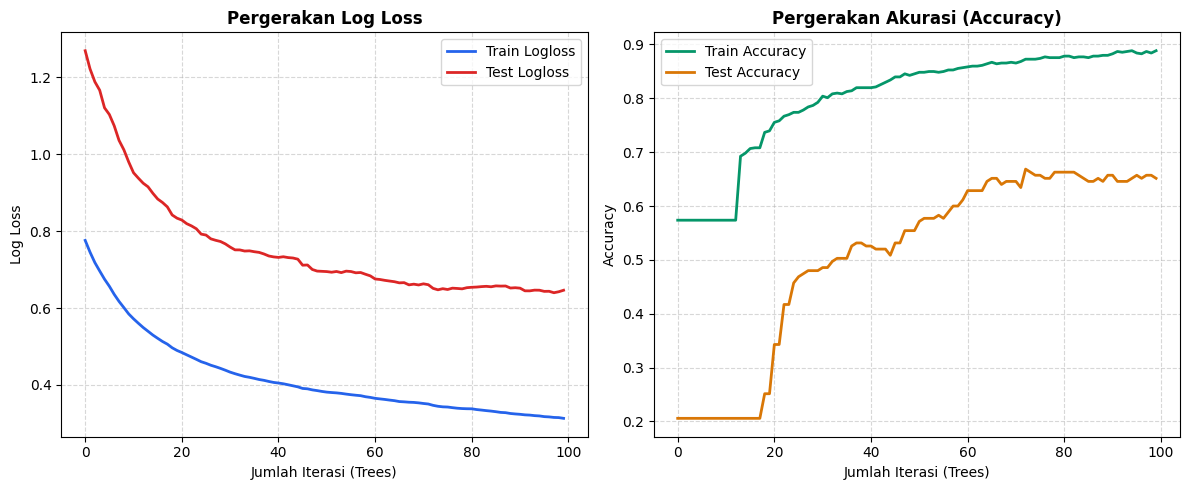

In [16]:
import matplotlib.pyplot as plt

# Ambil riwayat evaluasi (history) dari XGBoost
results = model.evals_result()

# Jumlah iterasi / estimator
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

# Buat kanvas grafik berukuran 12x5 (2 grafik bersebelahan)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ==========================================
# GRAFIK 1: LOGLOSS (Semakin turun semakin baik)
# ==========================================
ax[0].plot(x_axis, results['validation_0']['logloss'], label='Train Logloss', color='#2563EB', linewidth=2)
ax[0].plot(x_axis, results['validation_1']['logloss'], label='Test Logloss', color='#DC2626', linewidth=2)
ax[0].legend()
ax[0].set_title('Pergerakan Log Loss', fontweight='bold')
ax[0].set_xlabel('Jumlah Iterasi (Trees)')
ax[0].set_ylabel('Log Loss')
ax[0].grid(axis='both', linestyle='--', alpha=0.5)

# ==========================================
# GRAFIK 2: ACCURACY (Semakin naik semakin baik)
# ==========================================
# XGBoost mencatat metrik 'error'. Akurasi = 1.0 - error
train_acc = [1.0 - x for x in results['validation_0']['error']]
test_acc = [1.0 - x for x in results['validation_1']['error']]

ax[1].plot(x_axis, train_acc, label='Train Accuracy', color='#059669', linewidth=2)
ax[1].plot(x_axis, test_acc, label='Test Accuracy', color='#D97706', linewidth=2)
ax[1].legend()
ax[1].set_title('Pergerakan Akurasi (Accuracy)', fontweight='bold')
ax[1].set_xlabel('Jumlah Iterasi (Trees)')
ax[1].set_ylabel('Accuracy')
ax[1].grid(axis='both', linestyle='--', alpha=0.5)

# Rapikan dan simpan gambar
plt.tight_layout()
plt.savefig('model/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

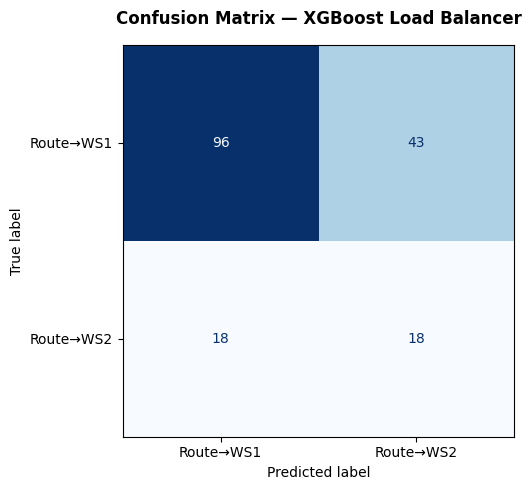

✅ Disimpan ke model/confusion_matrix.png


In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Route→WS1', 'Route→WS2'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix — XGBoost Load Balancer', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('model/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan ke model/confusion_matrix.png')

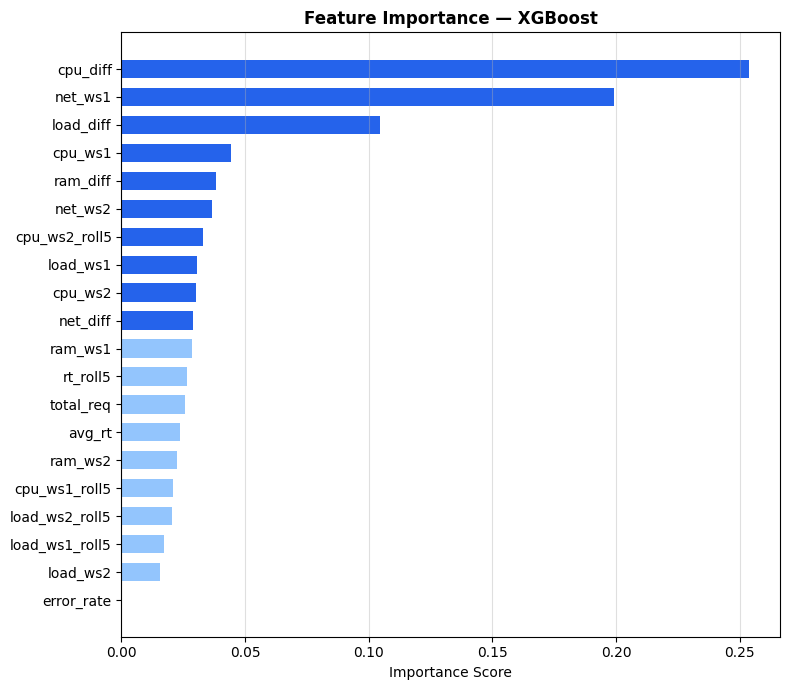

✅ Disimpan ke model/feature_importance.png


In [18]:
# Feature Importance
feat_imp_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2563EB' if imp > feat_imp_df['Importance'].median() else '#93C5FD'
          for imp in feat_imp_df['Importance']]
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color=colors, edgecolor='none', height=0.65)
ax.set_title('Feature Importance — XGBoost', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('model/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan ke model/feature_importance.png')

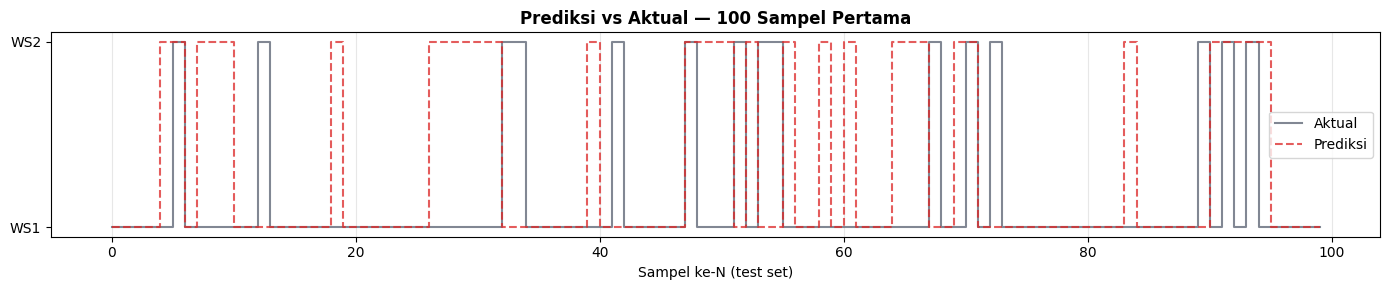

In [19]:
# Prediksi vs Aktual (100 sampel pertama)
n_show = min(100, len(y_test))
fig, ax = plt.subplots(figsize=(14, 3))
ax.step(range(n_show), y_test.values[:n_show], where='post',
        lw=1.5, color='#6B7280', label='Aktual',   alpha=0.85)
ax.step(range(n_show), y_pred[:n_show],         where='post',
        lw=1.5, color='#DC2626', label='Prediksi', alpha=0.75, linestyle='--')
ax.set_yticks([0, 1])
ax.set_yticklabels(['WS1', 'WS2'])
ax.set_xlabel('Sampel ke-N (test set)')
ax.set_title('Prediksi vs Aktual — 100 Sampel Pertama', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('model/prediction_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 13 — Simpan Model ke File .pkl

In [20]:
# Simpan model
joblib.dump(model,        PATH_MODEL)

# Simpan daftar fitur — urutan HARUS sama persis dengan saat training
joblib.dump(FEATURE_COLS, 'model/feature_names.pkl')

# Simpan konstanta normalisasi
joblib.dump({'RAM_MAX': RAM_MAX, 'NET_MAX': NET_MAX}, 'model/norm_constants.pkl')

print(f'✅ Model          → {PATH_MODEL}')
print(f'✅ Nama fitur     → model/feature_names.pkl')
print(f'✅ Norm constants → model/norm_constants.pkl')
print(f'\nUkuran model: {os.path.getsize(PATH_MODEL) / 1024:.1f} KB')

✅ Model          → model/xgb_load_balancer.pkl
✅ Nama fitur     → model/feature_names.pkl
✅ Norm constants → model/norm_constants.pkl

Ukuran model: 112.4 KB


---
## Step 14 — Uji Coba Inferensi (Simulasi Real-Time)

In [21]:
# Load ulang semua artefak (simulasi seperti di api.py)
loaded_model    = joblib.load(PATH_MODEL)
loaded_features = joblib.load('model/feature_names.pkl')
loaded_norms    = joblib.load('model/norm_constants.pkl')

RAM_MAX_loaded = loaded_norms['RAM_MAX']
NET_MAX_loaded = loaded_norms['NET_MAX']

# ── Simulasikan input real-time dari server
#    Ganti angka-angka ini dengan nilai aktual dari metrics_agent.py
cpu_ws1_now = 72.5
ram_ws1_now = 850.0
net_ws1_now = 120.0
cpu_ws2_now = 35.2
ram_ws2_now = 620.0
net_ws2_now = 95.0
avg_rt_now  = 320.0
total_req   = 25
error_rate  = 0.0

# Hitung load score (harus pakai RAM_MAX dan NET_MAX dari training)
load_ws1 = (0.50 * cpu_ws1_now +
            0.30 * (ram_ws1_now / RAM_MAX_loaded * 100) +
            0.20 * min(net_ws1_now / NET_MAX_loaded * 100, 100))

load_ws2 = (0.50 * cpu_ws2_now +
            0.30 * (ram_ws2_now / RAM_MAX_loaded * 100) +
            0.20 * min(net_ws2_now / NET_MAX_loaded * 100, 100))

sample_input = {
    'cpu_ws1'       : cpu_ws1_now,
    'ram_ws1'       : ram_ws1_now,
    'net_ws1'       : net_ws1_now,
    'cpu_ws2'       : cpu_ws2_now,
    'ram_ws2'       : ram_ws2_now,
    'net_ws2'       : net_ws2_now,
    'cpu_diff'      : cpu_ws1_now - cpu_ws2_now,
    'ram_diff'      : ram_ws1_now - ram_ws2_now,
    'net_diff'      : net_ws1_now - net_ws2_now,
    'load_diff'     : load_ws1   - load_ws2,
    'load_ws1'      : load_ws1,
    'load_ws2'      : load_ws2,
    'avg_rt'        : avg_rt_now,
    'total_req'     : total_req,
    'error_rate'    : error_rate,
    # Rolling features: gunakan nilai saat ini sebagai approksimasi
    'cpu_ws1_roll5' : cpu_ws1_now,
    'cpu_ws2_roll5' : cpu_ws2_now,
    'rt_roll5'      : avg_rt_now,
    'load_ws1_roll5': load_ws1,
    'load_ws2_roll5': load_ws2,
}

X_input    = pd.DataFrame([sample_input])[loaded_features]
prediction = loaded_model.predict(X_input)[0]
confidence = loaded_model.predict_proba(X_input)[0]

print('=== Hasil Inferensi ===')
print(f'  CPU  → WS1: {cpu_ws1_now}% | WS2: {cpu_ws2_now}%')
print(f'  RAM  → WS1: {ram_ws1_now} MB | WS2: {ram_ws2_now} MB')
print(f'  Load → WS1: {load_ws1:.2f} | WS2: {load_ws2:.2f}')
print(f'  Avg RT     : {avg_rt_now} ms | Error rate: {error_rate}')
print()
print(f'  Prediksi   : {"WS2 (1)" if prediction == 1 else "WS1 (0)"}')
print(f'  Confidence : WS1={confidence[0]:.3f} | WS2={confidence[1]:.3f}')
print()
print(f'  ➜ HAProxy harus route ke: {"WS2" if prediction == 1 else "WS1"}')

=== Hasil Inferensi ===
  CPU  → WS1: 72.5% | WS2: 35.2%
  RAM  → WS1: 850.0 MB | WS2: 620.0 MB
  Load → WS1: 68.73 | WS2: 41.36
  Avg RT     : 320.0 ms | Error rate: 0.0

  Prediksi   : WS2 (1)
  Confidence : WS1=0.013 | WS2=0.987

  ➜ HAProxy harus route ke: WS2


---
## Ringkasan Output

```
model/
├── xgb_load_balancer.pkl      ← model XGBoost
├── feature_names.pkl          ← urutan nama fitur
├── norm_constants.pkl         ← RAM_MAX & NET_MAX untuk normalisasi
├── label_distribution.png
├── confusion_matrix.png
├── feature_importance.png
└── prediction_vs_actual.png
```

### Integrasi ke api.py
File `api.py` yang sebelumnya sudah dibuat perlu diupdate untuk:
1. Load `norm_constants.pkl` saat startup
2. Gunakan `RAM_MAX` dan `NET_MAX` dari file tersebut saat menghitung load score
3. Gunakan `Net_Recv_KB` dari metrics agent sebagai input fitur `net_ws1`/`net_ws2`